In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

%config InlineBackend.figure_format = "retina"

from matplotlib.font_manager import FontProperties,fontManager
font_path = r'C:\Windows\Fonts\malgun.ttf'
fontManager.addfont(font_path)
plt.rc('font', family='Malgun Gothic')

font_prop = FontProperties(fname=font_path, size=20)
font_name = font_prop.get_name() 
plt.rc('axes', unicode_minus=False)

import warnings
warnings.filterwarnings(action='ignore')

In [2]:
# 1)번 문제
df_first = pd.read_csv(r'C:\ai\downloads\shareData\분양가격\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.head(4)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,...,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449


In [3]:
pd.options.display.max_columns =22

In [4]:
df_first.sample()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
6,울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,8493,8627,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215


In [5]:
df_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   지역        17 non-null     object
 1   2013년12월  17 non-null     int64 
 2   2014년1월   17 non-null     int64 
 3   2014년2월   17 non-null     int64 
 4   2014년3월   17 non-null     int64 
 5   2014년4월   17 non-null     int64 
 6   2014년5월   17 non-null     int64 
 7   2014년6월   17 non-null     int64 
 8   2014년7월   17 non-null     int64 
 9   2014년8월   17 non-null     int64 
 10  2014년9월   17 non-null     int64 
 11  2014년10월  17 non-null     int64 
 12  2014년11월  17 non-null     int64 
 13  2014년12월  17 non-null     int64 
 14  2015년1월   17 non-null     int64 
 15  2015년2월   17 non-null     int64 
 16  2015년3월   17 non-null     int64 
 17  2015년4월   17 non-null     int64 
 18  2015년5월   17 non-null     int64 
 19  2015년6월   17 non-null     int64 
 20  2015년7월   17 non-null     int64 
 21  2015년8월   17 non-n

In [6]:
df_first.set_index('지역',inplace=True)
df_first

,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
지역,,,,,,,,,,,,,,,,,,,,,
서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,9110,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,8403,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,10016,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,7707,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,8048,8038,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079
울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,8493,8627,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215
경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,10501,10397,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
세종,7601,7600,7532,7814,7908,7934,8067,8067,8141,8282,8527,8592,8560,8560,8560,8555,8546,8546,8671,8669,8695


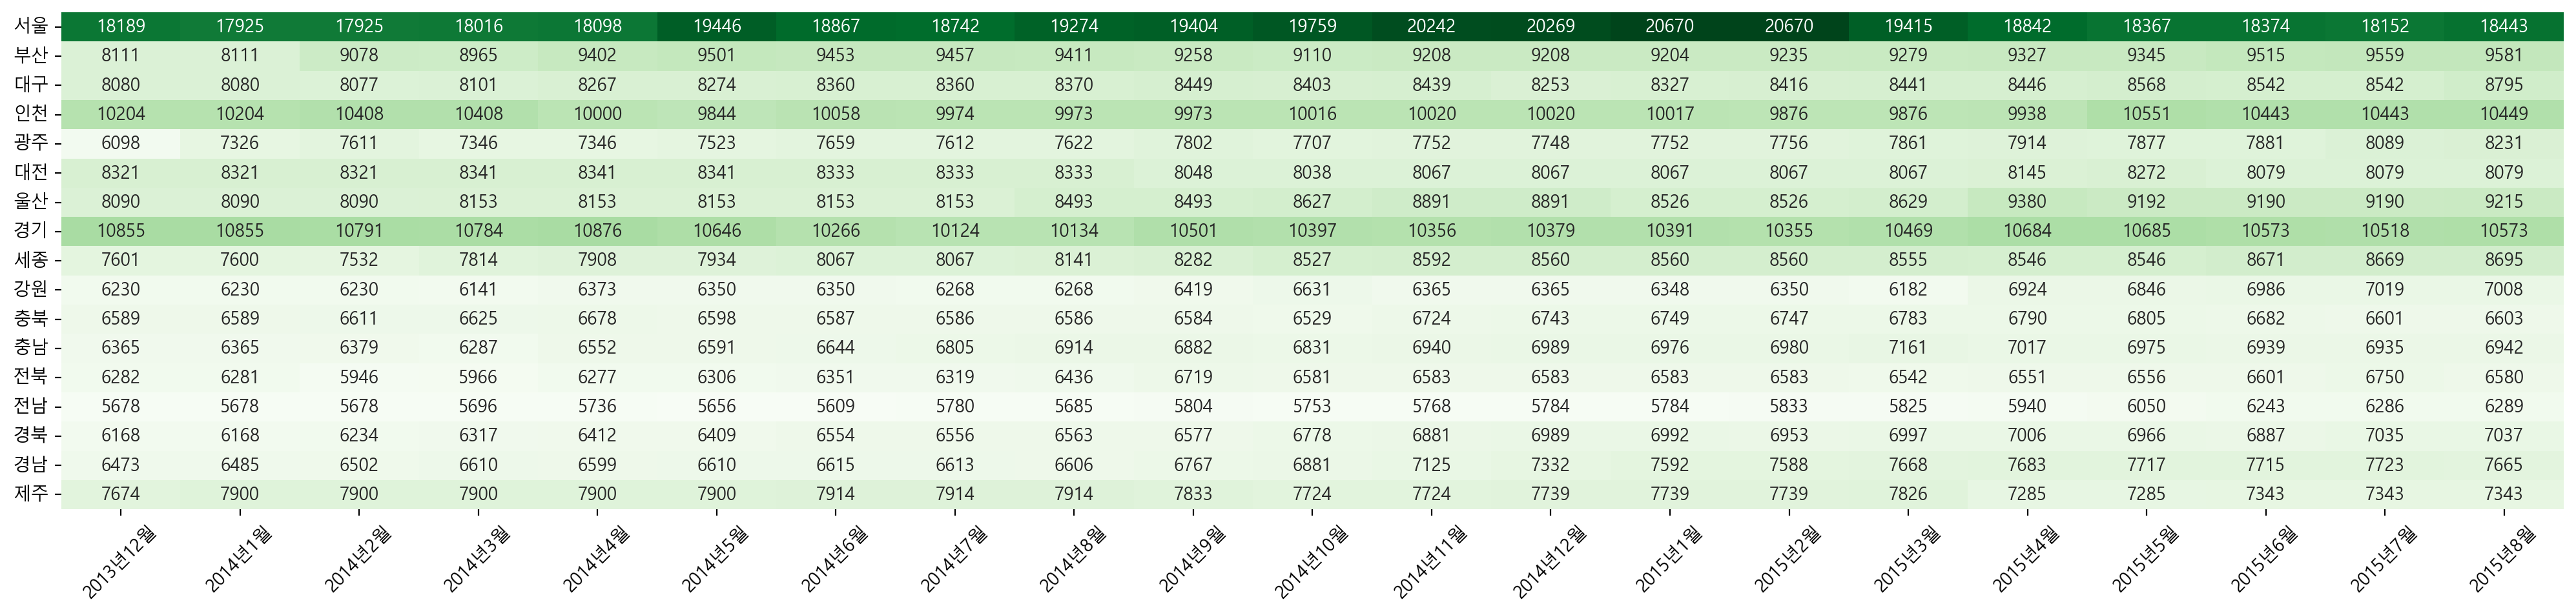

In [7]:
plt.figure(figsize=(25,5))
sns.heatmap(df_first, annot=True, fmt='d',cmap='Greens', cbar=False)
plt.xticks(rotation=45)
plt.ylabel(None)
plt.show()

In [8]:
df_first.isna()

,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
지역,,,,,,,,,,,,,,,,,,,,,
서울,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
부산,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
대구,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
인천,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
광주,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
대전,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
울산,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
경기,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
세종,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [114]:
#2)번 문제
df_last = pd.read_csv(r'C:\ai\downloads\shareData\분양가격\주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv',
                      encoding='cp949')
df_last.shape

(10880, 5)

In [115]:
df_last['분양가격(제곱미터당 천원)'].describe()

count     10035
unique     3637
top            
freq         95
Name: 분양가격(제곱미터당 천원), dtype: object

In [116]:
df_last.isna()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
10875,False,False,False,False,False
10876,False,False,False,False,True
10877,False,False,False,False,False
10878,False,False,False,False,True


In [117]:
df_last.isna().sum()

지역명                 0
규모구분                0
연도                  0
월                   0
분양가격(제곱미터당 천원)    845
dtype: int64

In [118]:
temp=pd.to_numeric(df_last['분양가격(제곱미터당 천원)'],errors='coerce')
nanidx = temp[temp.isna()].index
nanidx

Int64Index([   28,    29,    34,    81,   113,   114,   119,   166,   198,
              199,
            ...
            10793, 10816, 10818, 10823, 10838, 10839, 10858, 10863, 10876,
            10878],
           dtype='int64', length=973)

In [119]:
df_last[df_last['분양가격(제곱미터당 천원)'].str.strip()==''].shape[0]

126

In [120]:
df_last.loc[nanidx,'분양가격(제곱미터당 천원)'].unique()

array(['  ', nan, ' ', '-'], dtype=object)

In [121]:
df_last[df_last['분양가격(제곱미터당 천원)']=='-']

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
8861,대구,전용면적 60제곱미터이하,2024,6,-
8863,대구,전용면적 85제곱미터초과 102제곱미터이하,2024,6,-


In [122]:
def commadrop(row):
    row = row.copy()
    price=row['분양가격(제곱미터당 천원)']
    if pd.isna(price): 
        row['제곱미터당분양가격'] = np.nan
    elif price.strip()=='' or price=='-' : 
        row['제곱미터당분양가격'] = np.nan
    elif price.find(',') !=-1: 
        row['제곱미터당분양가격'] = float(price.replace(',',''))
    else:
        row['제곱미터당분양가격'] = float(price)
        
    return row


commadrop(df_last.loc[0]) 
commadrop(df_last.loc[28]) 
commadrop(df_last.loc[368]) 
commadrop(df_last.loc[8863])

지역명                                    대구
규모구분              전용면적 85제곱미터초과 102제곱미터이하
연도                                   2024
월                                       6
분양가격(제곱미터당 천원)                          -
제곱미터당분양가격                             NaN
Name: 8863, dtype: object

In [127]:
df_last = df_last.apply(commadrop, axis=1)

In [128]:
df_last[['분양가격(제곱미터당 천원)','제곱미터당분양가격']].isna().sum()

분양가격(제곱미터당 천원)    845
제곱미터당분양가격         973
dtype: int64

In [129]:
df_last.drop(['제곱미터당분양가격'], axis=1, inplace=True)
df_last.sample(1)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),전용면적
596,서울,전용면적 60제곱미터이하,2016,5,6638,60m²


In [131]:
def commadrop2(price):

    if pd.isna(price): 
        return np.nan
    elif price.strip()=='' or price=='-' : 
        return np.nan
    elif price.find(',') !=-1: 
        return float(price.replace(',',''))
    else:
        return float(price)
        
    return row


commadrop2(df_last.loc[0, '분양가격(제곱미터당 천원)']) 
commadrop2(df_last.loc[1, '분양가격(제곱미터당 천원)']) 
commadrop2(df_last.loc[28, '분양가격(제곱미터당 천원)']) 
commadrop2(df_last.loc[368, '분양가격(제곱미터당 천원)']) 

nan

In [132]:
df_last['제곱미터당분양가격']=df_last['분양가격(제곱미터당 천원)'].map(commadrop2)
df_last.iloc[8863:8866]

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),전용면적,제곱미터당분양가격
8863,대구,전용면적 85제곱미터초과 102제곱미터이하,2024,6,-,85m²~102m²,NaN
8864,대구,전용면적 102제곱미터초과,2024,6,5593,102m²~,5593.0
8865,광주,모든면적,2024,6,5471,모든면적,5471.0


In [133]:
pd.to_numeric(df_last['분양가격(제곱미터당 천원)'].str.replace(',',''),errors='coerce').isna().sum()

973

In [134]:
df_last['제곱미터당분양가격']=\
        pd.to_numeric(df_last['분양가격(제곱미터당 천원)'].str.replace(',',''),errors='coerce')
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   전용면적            10880 non-null  object 
 6   제곱미터당분양가격       9907 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 595.1+ KB


In [135]:
df_last['평당분양가격']=df_last['제곱미터당분양가격']*3.3
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   전용면적            10880 non-null  object 
 6   제곱미터당분양가격       9907 non-null   float64
 7   평당분양가격          9907 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 680.1+ KB


In [136]:
df_last[['제곱미터당분양가격','평당분양가격']].describe()

,제곱미터당분양가격,평당분양가격
count,9907.000000,9907.000000
mean,4291.544867,14162.098062
std,2125.581720,7014.419675
min,1868.000000,6164.400000
25%,2872.000000,9477.600000
50%,3798.000000,12533.400000
75%,4940.500000,16303.650000
max,22713.000000,74952.900000


In [137]:
df_last[['제곱미터당분양가격','평당분양가격']].skew()

제곱미터당분양가격    2.582328
평당분양가격       2.582328
dtype: float64

In [45]:
#3번 문제
df_last.groupby(['연도','지역명'])['평당분양가격'].mean().unstack().round(1)

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.1,11060.9,8459.2,7464.2,7916.7,9018.9,8190.6,10377.4,20315.7,8765.0,9367.6,10976.0,6798.9,7110.4,7951.1,7689.9,6828.8
2016,7162.9,11685.0,8496.7,7753.4,9190.7,10282.0,8910.7,10743.5,21753.4,8857.8,9582.6,11099.1,6936.6,6906.6,9567.5,7958.2,7133.3
2017,7318.8,12296.2,8806.6,8288.1,9599.7,12192.0,9912.9,11637.6,21864.1,9132.9,10630.2,11672.4,7413.2,7406.1,12628.5,8157.3,7462.6
2018,8219.3,14258.4,9327.7,8680.8,9527.0,12139.3,10234.1,12890.0,23202.2,10340.5,10241.4,11881.5,7929.8,8174.6,11936.0,8201.8,8149.3
2019,8934.5,15665.5,10697.6,9050.2,12111.7,14081.6,12619.2,13537.9,28286.8,11299.4,10216.2,13249.8,8219.3,8532.3,11828.5,8748.8,7970.9
2020,10302.4,15106.1,10919.3,9997.7,13406.5,15314.2,11238.8,13353.0,29781.0,11628.1,12837.6,14983.0,9562.4,8559.4,14192.9,9139.4,8359.0
2021,10291.3,14567.1,11302.3,11227.2,13709.8,15586.3,11994.2,14317.7,29380.4,12578.1,14192.0,15774.3,9980.8,9047.9,22302.3,9860.7,8822.4
2022,11644.2,16621.6,12455.7,12018.0,15095.9,16821.9,14113.9,18166.8,29128.5,11310.0,17903.8,17341.8,10635.5,10003.1,18953.8,11730.3,10033.5
2023,13409.4,20175.2,13283.2,13025.3,17957.9,17656.7,17917.3,20470.9,33230.6,12278.2,18832.1,16150.7,11846.7,10966.0,24095.9,12580.6,11104.0


In [ ]:
# 4)번 문제

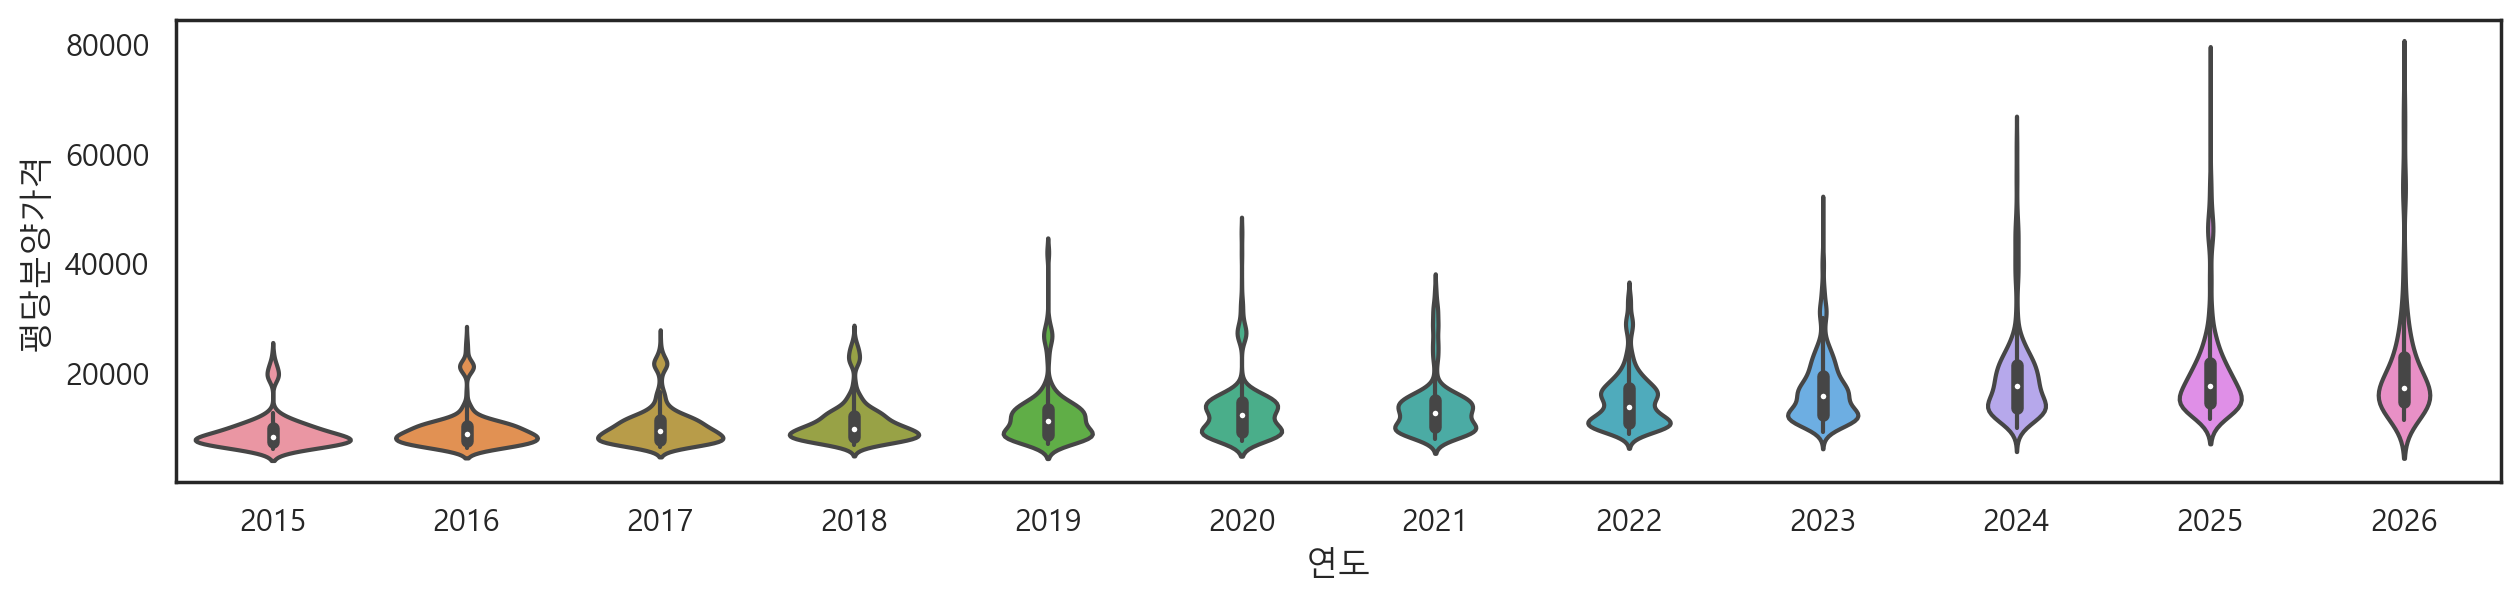

In [47]:
sns.set(style='white', rc={'figure.figsize':(15,3)})
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False) 
sns.violinplot(data=df_last, x='연도',y='평당분양가격')
plt.show()